In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'overture_base'
collection_id = 'vector-overture-base'

# Stac collection title
collection_title = 'Overture Base'

# Stac collection description
description = '''Overture base layers (type: infrastructure, land_use, land_cover, land, water).'''

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'update_time'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'id'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 1e6

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

geoparquet_path = '/data/raster/overture/base_processed/'
files = glob(os.path.join(geoparquet_path, '**/*.parquet'))

cols = [
    'id',
    'update_time',
    'type', 
    'subtype', 
    'class',
    'name',
    'sources',
    'wikidata',
    'level',
    'elevation',
    'surface',
    'is_salt',
    'is_intermittent',
    'source_tags',
    'geometry',
]

def load_clean_partial(file, cols):
    """Harmonize partial files before uploading."""
    gdf_part = geopandas.read_parquet(file)

    # # set UTC timestamp
    # # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
    # gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

    # # Fill in missing columns
    # missing_cols = list(set(cols) - set(gdf_part.columns))
    # for col in missing_cols:
    #     gdf_part[col] = None

    gdf_part['geometry'] = gdf_part['geometry'].make_valid()

    # Order the columns uniformly
    return gdf_part[cols]

len(files)

CPU times: total: 0 ns
Wall time: 5 ms


143

In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x27da09b7b50>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'overture_base',
 'collection_id': 'vector-overture-base',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/overture_base',
 'grid_directory': 'data/vectorstore/overture_base/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/overture_base/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/overture_base/grid=World(4326)/index',
 'dt_col': 'update_time',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'id',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['update_time', 'id'],
 'max_level': 26,
 'target_level': 14,
 'max_depth': 14,
 'max_inflation': 100,
 'target_rows': 1000000.0,
 'row_group_size': 100000.0,
 

# Chunked successive ingestion

In [4]:
# %%time
# n_chunks = 1
# for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
#     print('Chunk', i)
#     vs.partial_upload(
#         chunk,
#         defrag=False,
#         index=False,
#         geometry_area=False,
#         geometry_length=False,
#     )

In [5]:
%%time
for file in files:
    print(file)
    chunk = load_clean_partial(file, cols)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

/data/raster/overture/base_processed\type=infrastructure\part-00000-df7630cc-540a-4931-b01e-6f33b054dd61-c000.zstd.parquet
df_root 13198129
Time for indexing the root of each unique geometry in seconds 136.836
distributed over 18 partitions
Time for creating partitions in seconds 94.128
Time for writing GeoDataFrame to GeoParquet partitions 288.72
/data/raster/overture/base_processed\type=infrastructure\part-00001-df7630cc-540a-4931-b01e-6f33b054dd61-c000.zstd.parquet
df_root 13267309
Time for indexing the root of each unique geometry in seconds 140.768
distributed over 19 partitions
Time for creating partitions in seconds 88.28
Time for writing GeoDataFrame to GeoParquet partitions 295.734
/data/raster/overture/base_processed\type=infrastructure\part-00002-df7630cc-540a-4931-b01e-6f33b054dd61-c000.zstd.parquet
df_root 13339078
Time for indexing the root of each unique geometry in seconds 139.733
distributed over 18 partitions
Time for creating partitions in seconds 87.845
Time for wri

In [6]:
%%time
vs.unify_schemas()

Time for unify_schemas 840.748
CPU times: total: 10min 26s
Wall time: 14min


In [7]:
%%time
vs.defrag()

Time for defragging 6350.294
CPU times: total: 1h 15min 43s
Wall time: 1h 45min 50s


In [8]:
%%time
vs.repartition({})

level 0
source partition          target partition          records stay    records move   
0q                        0q1220020                 7840843         510516         
0q                        0q1220013                 7788226         52617          
0q                        0q1220011                 7603777         184449         
0q                        0q1220010                 7208831         394946         
0q                        0q1220031                 6660199         548632         
0q                        0q1220033                 6479594         180605         
0q                        0q120002                  6343815         135779         
0q                        0q122003                  6300782         43033          
0q                        0q122100                  6071127         229655         
0q                        0q122101                  5947213         123914         
0q                        0q122102                  5943329         

In [9]:
%%time
vs.defrag()

Time for defragging 4929.964
CPU times: total: 56min 41s
Wall time: 1h 22min 9s


In [10]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [14]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory, split_row_groups=False)
ddf

CPU times: total: 625 ms
Wall time: 19.4 s


,id,update_time,type,subtype,class,name,sources,wikidata,level,elevation,surface,is_salt,is_intermittent,source_tags,geometry,_root,grid,spatial_partition
npartitions=471,,,,,,,,,,,,,,,,,,
,object,"datetime64[ns, UTC]",object,object,object,object,object,object,float64,float64,object,bool,bool,object,geometry,object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

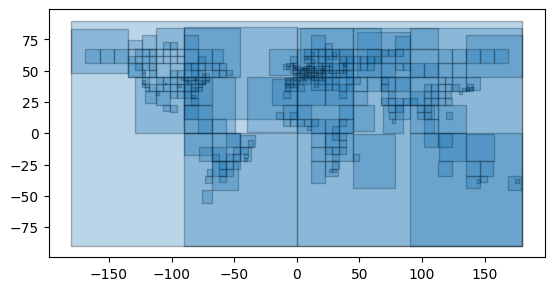

In [15]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [16]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)
bucket

'claimed-test'

In [ ]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [ ]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [17]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [18]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path claimed-test/vectorstore/overture_base/grid=World(4326)/geoparquet/spatial_partition=0q/55c085af764745e2a6e366e3d48048a3.parquet
schema.names ['id', 'update_time', 'type', 'subtype', 'class', 'name', 'sources', 'wikidata', 'level', 'elevation', 'surface', 'is_salt', 'is_intermittent', 'source_tags', 'geometry', '_root']
schema.types [DataType(string), TimestampType(timestamp[ns, tz=UTC]), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(double), DataType(double), DataType(string), DataType(bool), DataType(bool), DataType(string), DataType(binary), DataType(string)]
schema.metadata [b'overture_base', b'pandas', b'geo']
uploading to remote_path claimed-test/vectorstore/overture_base/grid=World(4326)/geoparquet/spatial_partition=0q01/36fe3336decc4270922a21c9a82e1d81.parquet
schema.names ['id', 'update_time', 'type', 'subtype', 'class', 'name', 'sources', 'wikidata', 'level', 'elevation', 'surface'

In [19]:
vs.stac_json_folder_submitted

'data/vectorstore/overture_base/grid=World(4326)/stac/submitted'

In [20]:
vs.stac_url

'https://stac-fastapi-sqlalchemy-nasageospatial-dev.cash.sl.cloud9.ibm.com'

In [21]:
vs.collection_id

'vector-overture-base'